In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("ai_job_market.csv")
df.head()

,job_id,company_name,industry,job_title,skills_required,experience_level,employment_type,location,salary_range_usd,posted_date,company_size,tools_preferred
0,1,Foster and Sons,Healthcare,Data Analyst,"NumPy, Reinforcement Learning, PyTorch, Scikit...",Mid,Full-time,"Tracybury, AR",92860-109598,2025-08-20,Large,"KDB+, LangChain"
1,2,"Boyd, Myers and Ramirez",Tech,Computer Vision Engineer,"Scikit-learn, CUDA, SQL, Pandas",Senior,Full-time,"Lake Scott, CU",78523-144875,2024-03-22,Large,"FastAPI, KDB+, TensorFlow"
2,3,King Inc,Tech,Quant Researcher,"MLflow, FastAPI, Azure, PyTorch, SQL, GCP",Entry,Full-time,"East Paige, CM",124496-217204,2025-09-18,Large,"BigQuery, PyTorch, Scikit-learn"
3,4,"Cooper, Archer and Lynch",Tech,AI Product Manager,"Scikit-learn, C++, Pandas, LangChain, AWS, R",Mid,Full-time,"Perezview, FI",50908-123743,2024-05-08,Large,"TensorFlow, BigQuery, MLflow"
4,5,Hall LLC,Finance,Data Scientist,"Excel, Keras, SQL, Hugging Face",Senior,Contract,"North Desireeland, NE",98694-135413,2025-02-24,Large,"PyTorch, LangChain"


In [3]:
# Salary Preprocessing

df[['min_salary','max_salary']] = df['salary_range_usd'].str.split('-', expand=True)

df['min_salary'] = df['min_salary'].astype(float)
df['max_salary'] = df['max_salary'].astype(float)

df['avg_salary'] = (df['min_salary'] + df['max_salary']) / 2 

In [4]:
df = df.drop(columns=['salary_range_usd', 'job_id', 'company_name', 'location'])

In [5]:
X = df.drop(columns=['avg_salary'])
y = df['avg_salary']

In [7]:
# Column Separation

categorical_cols = ['experience_level', 'industry', 'company_size', 'employment_type']
text_col = 'skills_required'

In [8]:
# Preprocessing Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_cols),
        ('text', TfidfVectorizer(max_features=100), text_col)
    ]
)

In [9]:
# MODELING

In [10]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Linear Regression

lr_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

In [13]:
y_pred_lr

array([117114.79696317, 120609.4570857 , 130013.61608173, 115379.85570188,
       124034.6760766 , 120988.0597429 , 125267.96169287, 119862.62579556,
       123780.07633183, 121539.0814884 , 122016.23158971, 121556.30908977,
       128273.36742765, 117398.29388229, 127378.23395156, 128205.23185414,
       115314.65304162, 119645.46301515, 125915.69142511, 123234.82732479,
       119295.51828092, 116541.9159779 , 126054.53908186, 122414.01337619,
       124478.52452947, 118502.41520035, 117106.68347488, 119290.73891612,
       119037.43662336, 124823.96410027, 121264.06941759, 121119.57844362,
       121824.07762168, 123530.33453431, 118202.29269976, 126021.64592238,
       124553.85516805, 124675.760297  , 124020.05249731, 119691.26066105,
       124301.76104425, 123847.1025291 , 124096.61394858, 131509.36420351,
       126191.89679973, 118581.38052525, 129396.26641133, 120472.29601921,
       127981.5541082 , 125393.06169756, 121605.60155979, 124521.0154477 ,
       114852.68291911, 1

In [12]:
# Random Forest

rf_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

In [14]:
y_pred_rf

array([116277.34 , 124283.075, 109914.555, 133994.1  , 130275.575,
       132122.54 , 111281.155, 122615.935, 134437.59 , 134330.405,
       119260.19 , 123875.585, 133014.85 , 114310.355, 120235.355,
       125839.305, 115416.545, 110663.575, 119457.765, 117889.615,
       125004.515, 126756.27 , 135416.49 , 119013.315, 112997.15 ,
       127831.465, 119771.555, 116862.49 , 115818.09 , 128928.93 ,
       140337.04 , 116693.605, 116751.655, 137338.17 , 125036.795,
       122394.19 , 125068.235, 122818.19 , 117862.725, 122653.215,
       112381.895, 121177.075, 103880.895, 124583.105, 135207.73 ,
       127624.07 , 130646.765, 131896.7  , 116450.18 , 125863.78 ,
       120196.305, 134034.065,  91305.71 , 127903.71 , 122846.645,
       128825.385, 135153.865, 126020.72 , 143226.805, 123018.06 ,
       123602.345, 128155.05 , 109069.855, 129647.575, 112919.93 ,
       134406.315, 126844.2  , 115131.785, 119609.26 , 118941.165,
       131143.845, 113350.085, 157911.285, 116922.71 , 119433.

In [15]:
# EVALUATION

In [16]:
# Evaluation Function

def evaluate_model(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    
    print(f"{name} Performance:")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R2 Score: {r2:.2f}")
    print("-" * 30)

In [17]:
# Evaluate Models

evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_rf, "Random Forest")

Linear Regression Performance:
MAE: 30884.75
RMSE: 36440.99
R2 Score: -0.03
------------------------------
Random Forest Performance:
MAE: 30876.99
RMSE: 36677.20
R2 Score: -0.04
------------------------------


In [ ]:
# Feature Importance

# Get feature names
ohe = rf_pipeline.named_steps['preprocessing'].named_transformers_['cat']
tfidf = rf_pipeline.named_steps['preprocessing'].named_transformers_['text']

cat_features = ohe.get_feature_names_out(categorical_cols)
text_features = tfidf.get_feature_names_out()

all_features = list(cat_features) + list(text_features)

# Get importance
importances = rf_pipeline.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': all_features,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
32,pytorch,0.045241
23,keras,0.045140
16,cuda,0.043317
27,mlflow,0.042796
36,tensorflow,0.042530
29,pandas,0.041973
19,fastapi,0.041776
24,langchain,0.040037
13,aws,0.039226
31,python,0.039111


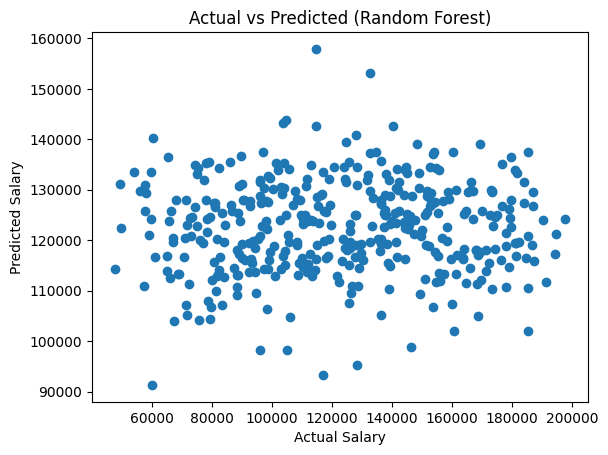

In [19]:
# Prediction vs Actual Plot

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()